# Breast Cancer Wisconsin Diagnostic

## 1. Carregamento e Limpeza Básica (Pré-processamento)

### 1.1. O Método de Coleta (A Origem dos Dados)

Os dados deste projeto não foram tirados de um exame de sangue comum ou de uma tomografia. Eles são derivados de um procedimento chamado PAAF (Punção Aspirativa por Agulha Fina). Nesse exame, o médico insere uma agulha fina na massa (tumor) do paciente, extrai um fluido contendo células e o coloca em uma lâmina de microscópio. Uma foto digital de alta resolução dessa lâmina é tirada, e um software de processamento de imagem analisa o núcleo dessas células.


Os números do dataset são medições matemáticas exatas da forma e do tamanho desses núcleos celulares.


As Variáveis Diretas (As Características Biológicas)
O software de imagem calcula 10 características morfológicas para o núcleo de cada célula encontrada na lâmina. Estas são as características base.


### 1.2. O Desdobramento Estatístico: Média, Erro Padrão e Pior


A lâmina de microscópio de um único paciente não possui apenas uma célula; ela possui dezenas ou centenas. O software mede as 10 características acima para todas as células da lâmina.

Para que o dataset não tenha tamanhos diferentes para cada paciente, os cientistas consolidaram essas dezenas de medições celulares em 3 métricas estatísticas para cada característica. Como existem 10 características, isso resulta nas 30 features (10 x 3 = 30) que vemos no código:

•	O Bloco _mean (Ex: radius_mean):  
A média aritmética daquela característica considerando todas as células da lâmina.  
o	Exemplo: Se o software viu 50 células, o radius_mean é a soma de todos os raios dividida por 50. Dá uma visão geral do tumor.

•	O Bloco _se (Erro Padrão / Standard Error):  
O erro padrão da média, que indica a dispersão/variação dos tamanhos.
O que significa biologicamente: Se um tumor benigno tem células saudáveis, todas elas terão tamanhos muito parecidos (Erro Padrão baixo). Se um tumor é maligno e caótico, ele terá algumas células minúsculas e outras gigantes (Erro Padrão alto).

•	O Bloco _worst (Pior / Máximo):  
A média matemática das três maiores (ou piores) células encontradas naquela lâmina específica.  
A importância clínica: No câncer, a média pode ser enganosa. Um tumor pode ter 90% de células normais e 10% de células extremamente deformadas e mortais. O bloco _worst isola exatamente essas células aberrantes, garantindo que o algoritmo preste atenção no pior cenário de cada paciente. Como discutimos, são frequentemente as variáveis mais poderosas para o diagnóstico.

### 1.3. Preprocessamento propriamente dito

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

In [2]:
# Carrega os dados
# train2.csv -> base ROTULADA (tem a coluna 'diagnosis') -> usada no TREINAMENTO
# test2.csv  -> base SEM rótulo (não possui 'diagnosis') -> usada só na PREVISÃO final
df = pd.read_csv("train2.csv")
df_test2 = pd.read_csv("test2.csv")

print(f"train2 (treino):          {df.shape}")
print(f"test2  (previsão final):  {df_test2.shape}")

train2 (treino):          (569, 31)
test2  (previsão final):  (40, 30)


In [3]:
# Exibe as primeiras 5 linhas para checar se deu certo
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Exibe informações sobre o dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

Mostra valores em todo o DataFrame

Limpeza de colunas inúteis:

In [5]:
# Remove a coluna inútil (axis=1 significa coluna)
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Verifica o novo formato da base (deve ter 569 linhas e 31 colunas)
print(f"Formato atual da base: {df.shape}")

Formato atual da base: (569, 31)


Valida que nao há valor ausente em todo o DataFrame

In [6]:
missing_values = df.isnull().sum().sum()
print(f"Total de valores ausentes no dataset: {missing_values}")

Total de valores ausentes no dataset: 0


Tratamento da variável alvo (target)

In [7]:
# Mapeia as letras para binário
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Verifica se a transformação funcionou e a proporção de cada classe
print(df['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


Divisão do dataset em features X e target y

In [8]:
# X recebe tudo, exceto a coluna diagnosis
X = df.drop(columns=['diagnosis'])

# y recebe apenas a coluna diagnosis
y = df['diagnosis']

Como o `test2.csv` não tem rótulos, não dá para medir o desempenho diretamente nele. Então separamos uma parte do **próprio `train2`** (80% treino / 20% validação) para conseguir avaliar os modelos de forma honesta. Para evitar o vazamento de dados (*data leakage*), essa separação é feita **antes** de qualquer escala ou normalização.

In [9]:
# O test2.csv não tem rótulos, então separamos uma parte do PRÓPRIO train2 para VALIDAÇÃO.
# É sobre essa parte que as métricas das Seções 5.x são calculadas.
# Mantemos os nomes X_test/y_test para o restante do notebook seguir funcionando,
# mas lembre-se: aqui "teste" = validação interna vinda do train2.

# Divide os dados mantendo a proporção das classes (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Tamanho do Treino (X_train):     {X_train.shape}")
print(f"Tamanho da Validação (X_test):   {X_test.shape}")

Tamanho do Treino (X_train):     (455, 30)
Tamanho da Validação (X_test):   (114, 30)


Garante que a proporção de câncer maligno/benigno ficou idêntica no treino e na validação. Ambas as divisões terão aproximadamente 62.7% de benignos e 37.3% de malignos.

In [10]:
print("Proporção de classes no Treino:")
print(y_train.value_counts(normalize=True))

print("\nProporção de classes no Teste:")
print(y_test.value_counts(normalize=True))


Proporção de classes no Treino:
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Proporção de classes no Teste:
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


### 1.4. Output do preprocessamento

 **4 variáveis cruciais obtidas**: X_train, X_test, y_train e y_test

## 2. Análise Exploratória

### 2.1. Identificação de Outliers

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define um estilo bonito para os gráficos
sns.set_theme(style="whitegrid")


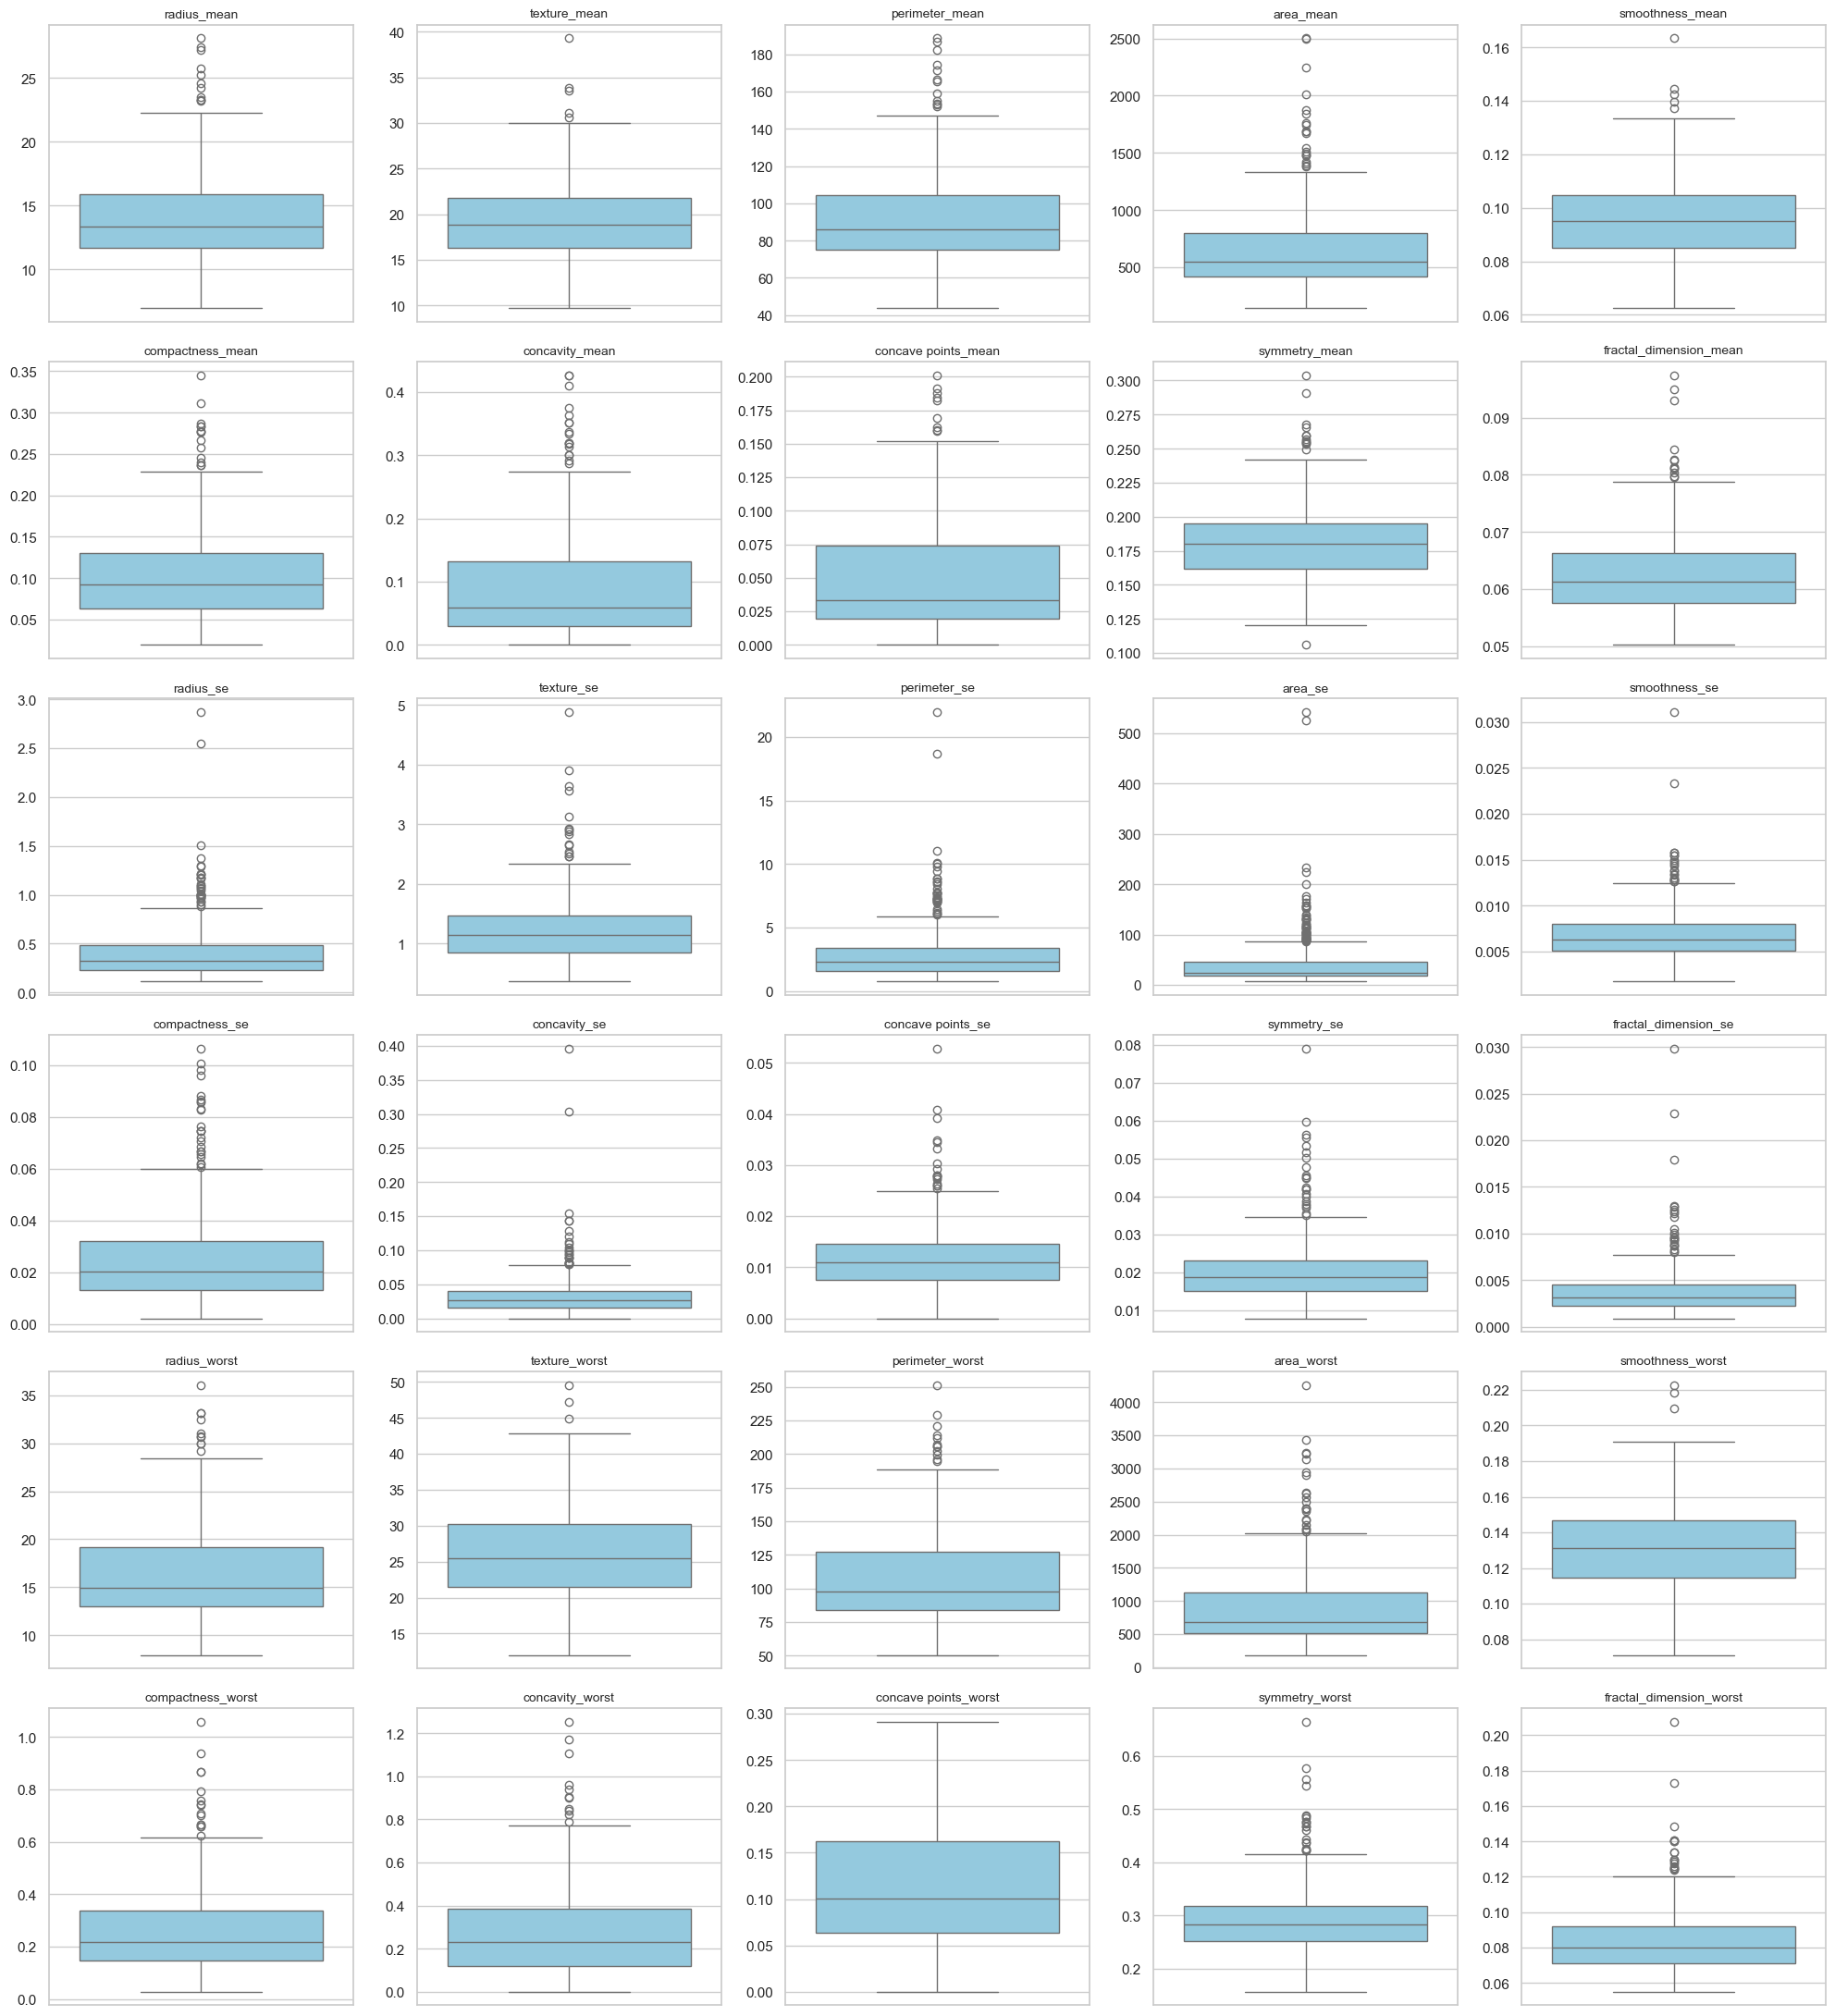

In [12]:
# Cria uma grade de subplots: 6 linhas e 5 colunas (totalizando as 30 features)
fig, axes = plt.subplots(6, 5, figsize=(20, 22))
axes = axes.flatten() # Transforma a matriz de eixos em uma lista simples

# Plota cada feature em seu próprio gráfico de forma direta
for i, col in enumerate(X_train.columns):
    sns.boxplot(y=X_train[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("") # Remove o label repetido para limpar o visual

# Remove subplots vazios caso sobrasse algum espaço
plt.tight_layout()
plt.show()


Como as variáveis do dataset têm tamanhos muito discrepantes — algumas passam de mil e outras são menores que um —, a gente precisou padronizar a escala dos dados. Isso é importante, já que escolhemos trabalhar com modelos lineares e estatísticos probabilísticos.

Escolhemos usar o RobustScaler porque o câncer de mama gera um comportamento celular muito caótico, o que traz vários outliers reais no dataset. A ideia aqui não é apagar esses valores, já que eles indicam tumores graves e são dados médicos valiosíssimos. Usando a mediana e o IQR, o RobustScaler impede que esses outliers distorçam a regra de padronização, mantendo a escala justa para o grosso dos dados.


Só que vale um aviso: o RobustScaler mantém os outliers ali (ele só calibra a escala), modelos como os testados ainda são impactados pelos outliers.

**Como os outliers e as escalas discrepantes podem afetar os modelos?**

**Regressão Logística (LR)**


A Regressão Logística tenta traçar uma linha reta (um hiperplano) que separa os tumores benignos dos malignos, minimizando o erro logístico. Um outlier localizado muito longe da fronteira correta vai "puxar" essa linha em sua direção para tentar não errá-lo. Isso inclina a reta e faz o modelo errar vários dados normais que estavam perto da fronteira original.

Precisa que os valores estejam na mesma escala.


**Naive Bayes (GaussianNB)**

O Naive Bayes Gaussiano assume que cada atributo segue uma curva normal (distribuição de Gauss). Ele calcula a média e a variância dos atributos para cada classe. Como os outliers distorcem drasticamente a média e a variância, a curva calculada pelo modelo vai ficar "gorda" ou deslocada, fazendo o algoritmo errar as probabilidades dos casos normais.

O Naive Bayes não se importa com ordens de grandeza diferentes (ele calcula cada coluna de forma isolada, então não precisa de escala para funcionar).


**Análise Discriminante Linear (LDA)**

O LDA assume três coisas: os dados são normais, as variáveis têm a mesma escala/variância e, crucialmente, que todas as classes compartilham a mesma matriz de covariância. Os outliers destroem completamente o cálculo da covariância. Se um outlier inflar a variância de uma variável na classe maligna, a premissa de que as matrizes são iguais cai por terra, arruinando a matemática do LDA.

Exige dados escalados.

**Análise Discriminante Quadrática (QDA)**


Ao contrário do LDA, o QDA permite que cada classe tenha sua própria matriz de covariância (por isso a fronteira de decisão dele é curva/quadrática e não uma linha reta). Os outliers ainda vão distorcer as médias e covariâncias locais de cada classe, mas o impacto pode ser menor do que no LDA porque o QDA é mais flexível.

Também exige dados escalados.

### 2.2. Gráfico de Distribuição do Target (Balanceamento de Classes)

A gente precisa saber se a base tem muito mais casos benignos do que malignos, pois bases muito desbalanceadas exigem técnicas especiais

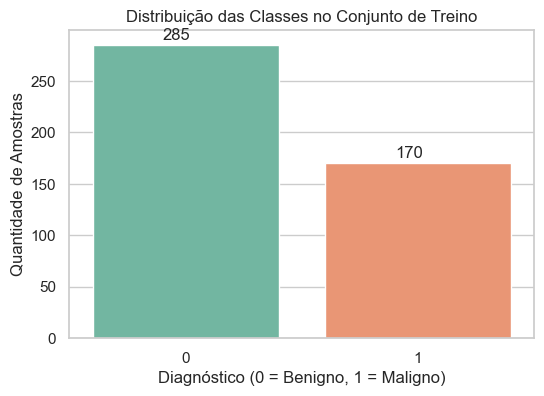

In [13]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_train, hue=y_train, palette="Set2", legend=False)
plt.title("Distribuição das Classes no Conjunto de Treino")
plt.xlabel("Diagnóstico (0 = Benigno, 1 = Maligno)")
plt.ylabel("Quantidade de Amostras")

# Adiciona os números em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 5))

plt.show()


O resultado mostra que há um leve desbalanço (mais benignos), mas nada crítico que impeça o treinamento direto.

### 2.3. Análise de Correlação e Retirada de Features via Mapa de Calor (Heatmap)
Como parte da etapa de Análise Exploratória de Dados (EDA) e Pré-processamento, foi construído um Mapa de Calor (Heatmap) de Correlação. O objetivo principal desta abordagem visual foi identificar e quantificar a relação linear entre as variáveis independentes (features) do conjunto de dados de diagnóstico de câncer de mama, visando mitigar problemas de multicolinearidade antes da etapa de modelagem preditiva.  
##Fundamentação Matemática: O Coeficiente de Pearson (r)
A base matemática do mapa de calor é o Coeficiente de Correlação de Pearson, representado por r. Esta métrica estatística avalia a força e a direção da relação linear entre duas variáveis contínuas, variando em um intervalo de -1 a 1:  

•	r --> 1: Indica uma correlação positiva forte (as variáveis crescem juntas, como raio e área do tumor).  
•	r --> -1: Indica uma correlação negativa forte (comportamento inversamente proporcional).  
•	r --> 0: Indica ausência de correlação linear (variáveis independentes).\

##Interpretação Visual da Matriz
Para viabilizar a análise simultânea das 30 variáveis originais (que gerariam uma matriz de 900 coeficientes), o Heatmap atua como um tradutor visual.  
Utilizando uma escala de cores divergente (paleta coolwarm), a carga cognitiva da análise é reduzida drasticamente. Tons quentes e escuros (vermelho) foram mapeados para correlações positivas extremas, enquanto tons frios e escuros (azul) representaram correlações negativas. A diagonal principal da matriz apresentou valor constante igual a 1, visto que representa a correlação de uma variável consigo mesma.  






Como existem 30 variáveis, plotar todas de uma vez fica confuso. Vamos selecionar apenas as variáveis de Média (_mean) para ver como elas se relacionam.

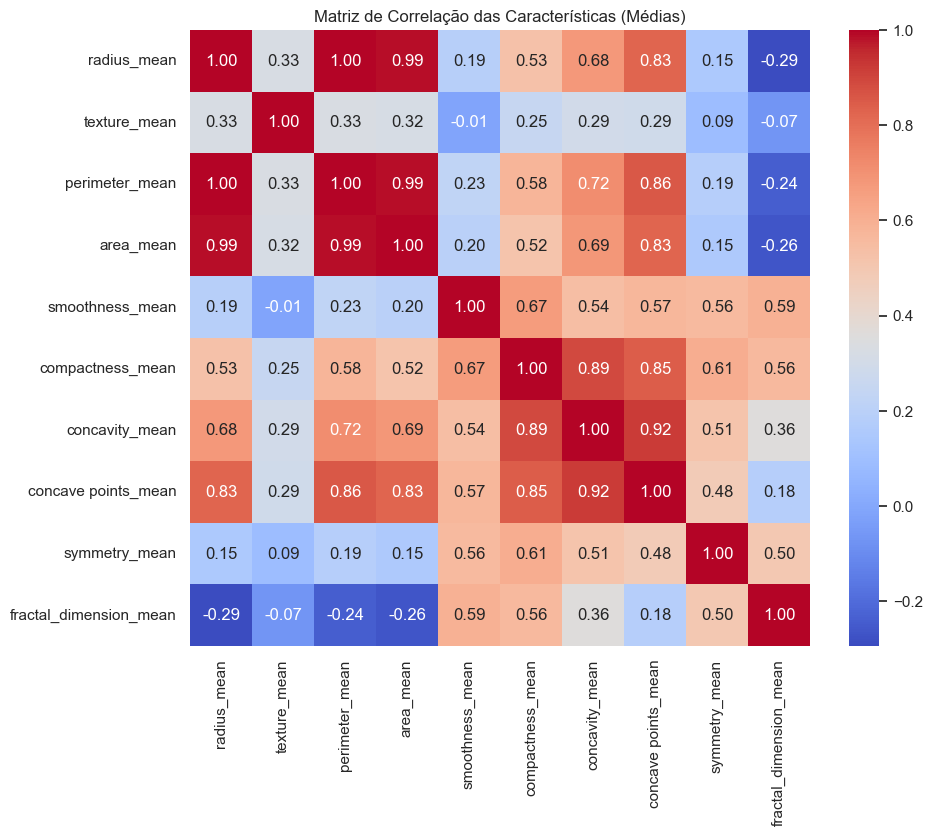

In [14]:
# Filtra apenas as colunas que contêm a palavra '_mean'
mean_features = [col for col in X_train.columns if '_mean' in col]

# Calcula a matriz de correlação
corr_matrix = X_train[mean_features].corr()

# Plota o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação das Características (Médias)")
plt.show()


Duas variáveis são quentes se tiverem forte colinearidade

### 2.4. Elencando as conclusões da análise exploratória

#### Critério de Corte e Eliminação de Redundância Dimensional
Durante a análise visual da matriz, observou-se uma alta densidade de agrupamentos vermelhos, indicando severa multicolinearidade geométrica (ex: radius_mean, perimeter_mean e area_mean possuíam r > 0.95).

Para garantir a estabilidade dos modelos supervisionados — especialmente a Regressão Logística, que sofre instabilidade na convergência dos pesos em cenários multicolineares, e o Naive Bayes, cuja premissa de independência de variáveis seria violada —, foi estabelecido um limite heurístico de corte de 0.85 em valor absoluto.

A escolha deste limite baseia-se no Coeficiente de Determinação (R^2):

R^2 = 0.85^2 aprox 0.7225

Isso implica que, ao reter variáveis com correlação superior a 0.85, o modelo estaria processando features onde mais de 72% da informação contida em uma já estaria perfeitamente explicada pela outra.

#### Conclusões
1. Redundância Dimensional (Geométrica): As características de raio, perímetro e área possuem correlação linear quase perfeita (r aproximadamente igual a 0.98). Isso prova matematicamente que o volume e o contorno celular crescem de forma estritamente proporcional.

2. Violação de Premissas do Naive Bayes: A forte interdependência das variáveis anula a hipótese de independência do Naive Bayes. O grupo conclui antecipadamente que o Naive Bayes servirá como um balizador inferior de desempenho, sendo esperado que ele distorça as probabilidades finais.

3. Viabilidade do Dataset (Equilíbrio de Classes): A análise do gráfico de barras ("Distribuição das Classes no Conjunto de Treino") revelou que a base possui um leve desbalanceamento (aproximadamente 63% benignos e 37% malignos). Conclui-se que não há necessidade de aplicar técnicas severas de reamostragem (como SMOTE), mas reforça-se que a acurácia isolada será uma métrica enganosa, elegendo-se o Recall como métrica norteadora devido à gravidade médica de um falso negativo.

## 3. Tratamento Final dos Dados (A partir da análise exploratória)

### 3.1. Filtragem de features correlacionadas

In [15]:
import numpy as np
import pandas as pd

# 1. Calcula a matriz de correlação absoluta
corr_matrix = X_train.corr().abs()

# 2. Seleciona o triângulo superior da matriz (para não olhar o espelho da diagonal)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Encontra colunas com correlação maior que 0.85
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

print(f"Colunas identificadas pelo Heatmap para exclusão ({len(to_drop)}):")
print(to_drop)

# 4. Cria os novos conjuntos de dados filtrados
X_train_filtered = X_train.drop(columns=to_drop)
X_test_filtered = X_test.drop(columns=to_drop)


Colunas identificadas pelo Heatmap para exclusão (13):
['perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']


Visualização dos gráficos após a retirada das features redundantes


 Heatmap Completo

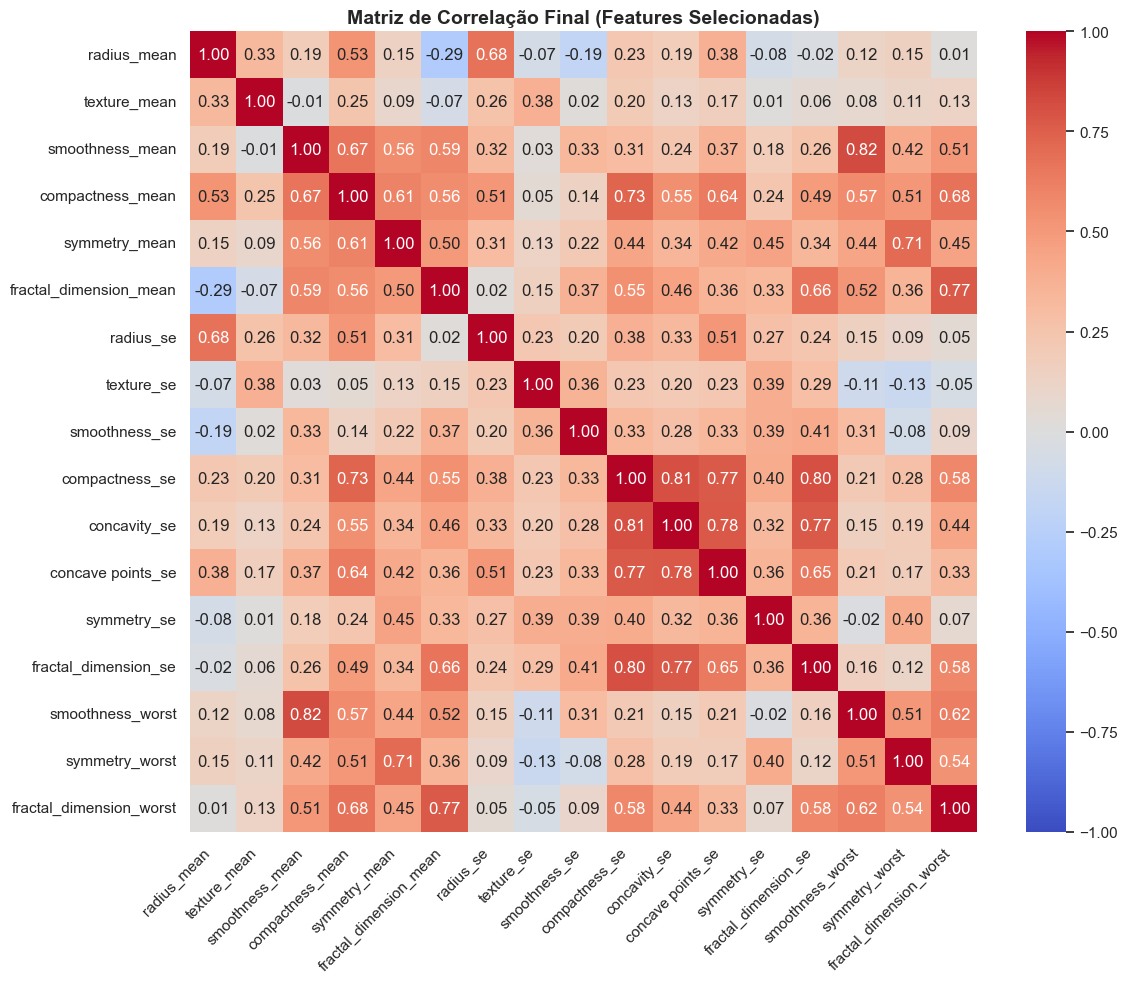

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcula a nova matriz de correlação APENAS com as features que sobreviveram
corr_matrix_final = X_train_filtered.corr()

# 2. Configura o tamanho da figura (pode ser um pouco menor que o original, já que temos menos features)
plt.figure(figsize=(12, 10))

# 3. Plota o Heatmap
# Usamos vmin=-1 e vmax=1 para manter a mesma escala de cores do gráfico original e permitir uma comparação justa
sns.heatmap(
    corr_matrix_final,
    annot=True,          # Mostra os números dentro dos quadrados
    fmt=".2f",           # Formata para 2 casas decimais
    cmap="coolwarm",     # Azul para inverso, Vermelho para direto
    cbar=True,           # Mostra a barra lateral de escala
    vmin=-1,             # Trava o mínimo da cor em -1
    vmax=1               # Trava o máximo da cor em 1
)

# 4. Acabamento
plt.title("Matriz de Correlação Final (Features Selecionadas)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Inclina os nomes embaixo para não encavalar
plt.tight_layout()
plt.show()

### 3.2. Análise das distribuições para tentar entender a relação das variáveis com as classificações

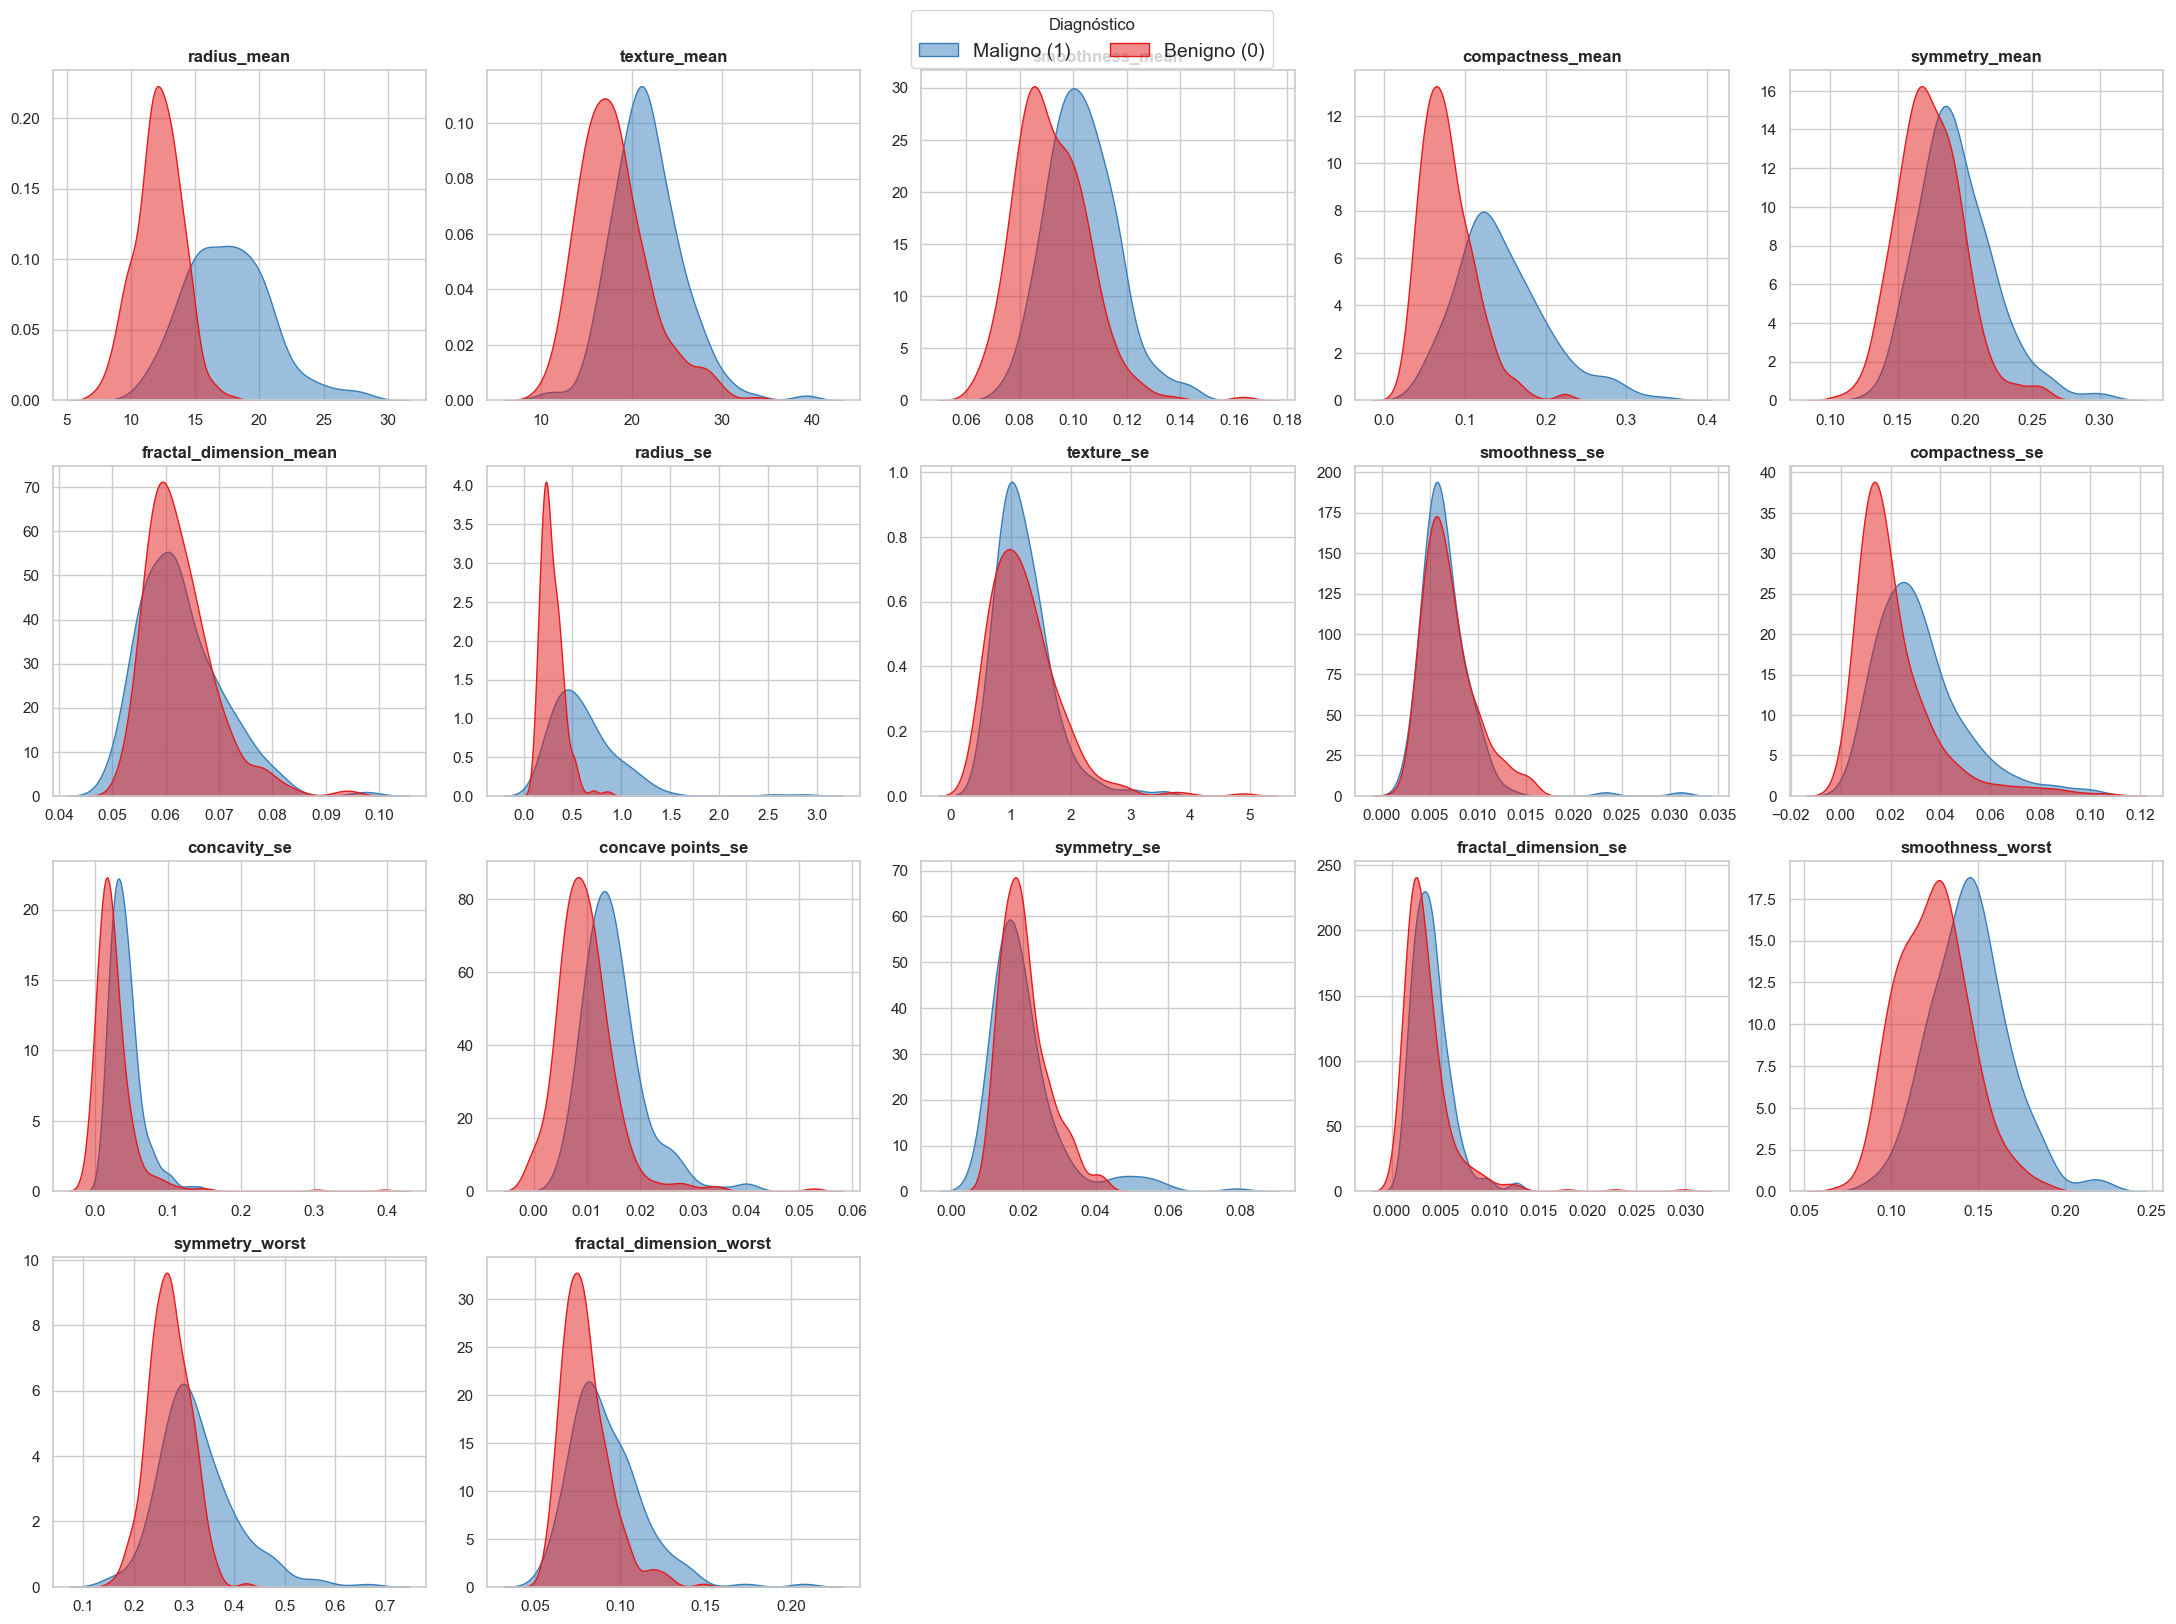

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Atenção aqui: Usamos o X_train_filtered em vez do X_train
dados_finais = X_train_filtered

# Calcula automaticamente o número de linhas baseado nas features que SOBRARAM
colunas = 5
linhas = math.ceil(len(dados_finais.columns) / colunas)

fig, axes = plt.subplots(linhas, colunas, figsize=(22, 4 * linhas))
axes = axes.flatten()

sns.set_theme(style="whitegrid")

for i, coluna in enumerate(dados_finais.columns):
    sns.kdeplot(
        data=dados_finais,
        x=coluna,
        hue=y_train,
        fill=True,
        palette='Set1',
        alpha=0.5,
        common_norm=False,
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(coluna, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

fig.legend(labels=['Maligno (1)', 'Benigno (0)'], loc='upper center', ncol=2, fontsize=14, title="Diagnóstico", bbox_to_anchor=(0.5, 1.02))

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Análise do Poder de Separação das Variáveis (KDE Plots)

Para que um algoritmo de classificação consiga distinguir eficazmente entre tumores benignos e malignos, ele precisa de variáveis (features) que apresentem comportamentos distintos para cada classe. Através dos gráficos de densidade de probabilidade (KDE Plots), podemos visualizar o quão "fácil" ou "difícil" será o trabalho do modelo:

Alta Separação (Fronteira Clara): Variáveis como radius_worst, perimeter_worst e area_worst apresentam duas curvas distintas (formando duas "montanhas") com pouca intersecção. Estas são as features mais poderosas do dataset, pois criam uma fronteira de decisão limpa: valores baixos indicam alta probabilidade de tumor benigno, e valores altos, maligno.

Alta Sobreposição (Ruído): Variáveis atreladas ao Erro Padrão, como smoothness_se, symmetry_se e fractal_dimension_mean, mostram curvas quase perfeitamente sobrepostas (um cenário de "eclipse"). Isso indica que, para essas características, tumores benignos e malignos são matematicamente indistinguíveis, adicionando pouco ou nenhum valor preditivo ao aprendizado da máquina.

Validação de Assimetria e Outliers: A longa 'cauda' observada estendendo-se para a direita nas curvas dos casos malignos reitera visualmente a presença de valores biológicos extremos e severos, validando matematicamente a nossa escolha metodológica pelo uso do algoritmo RobustScaler na etapa de pré-processamento.

### 3.3. Padronização dos dados (coloca os dados na mesma escala)

Os dados têm ordens de grandeza muito diferentes, logo padronizar é importante. Vamos usar o RobustScaler (por padrão) para deixar os valores das features na mesma escala (média 0 e desvio padrão 1).   
O método fit_transform() é usado apenas no treino para o modelo aprender a escala (aqui, nós aprendemos e aplicamos a escala). No teste, usamos .transform() para **apenas** aplicar a escala já aprendida, sem espiar os dados de teste. Assim, os dados em escala terão o mesmo significado.

In [18]:
# =====================================================================
# CONFIGURAÇÃO: Escolha o tipo de escala aqui
# Opções: 'padrao' (StandardScaler) ou 'robusto' (RobustScaler)
# =====================================================================
TIPO_ESCALA = 'robust'  # Se os outliers atrapalharem, mude aqui para 'robusto'

# Inicializa o padronizador escolhido
if TIPO_ESCALA == 'padrao':
    scaler = StandardScaler()
    print("Usando StandardScaler (Foco na Média)")
else:
    scaler = RobustScaler()
    print("Usando RobustScaler (Fose nos Quartis - Proteção contra Outliers)")

Usando RobustScaler (Fose nos Quartis - Proteção contra Outliers)


Com a técnica de escala escolhida, obtemos as versões padronizadas de X_train_filtered e X_test_filtered

In [19]:
# Ajusta e transforma os dados de treino
X_train_scaled = scaler.fit_transform(X_train_filtered)

# Apenas transforma os dados de teste
X_test_scaled = scaler.transform(X_test_filtered)

# Converte de volta para DataFrame para manter os nomes das colunas organizados
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_filtered.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_filtered.columns)

print("Dados padronizados com sucesso!")


Dados padronizados com sucesso!


## 4. Modelagem (Regressão Logística/Naive Bayes/LDA/QDA)

### 4.1. Modelagem I (com Holdout e sem ajuste de hiperparâmetros)


Importação dos Modelos sem validação

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

#### 4.1.1. Treinamento dos modelos


In [22]:
# 1. Regressão Logística
model_lr = LogisticRegression(max_iter=10000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

# 2. LDA
model_lda = LinearDiscriminantAnalysis()
model_lda.fit(X_train_scaled, y_train)

# 3. QDA
model_qda = QuadraticDiscriminantAnalysis()
model_qda.fit(X_train_scaled, y_train)

# 4. Naive Bayes Gaussiano
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)

GaussianNB()

#### 4.1.2. Geração de Previsões

In [23]:
y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_lda = model_lda.predict(X_test_scaled)
y_pred_qda = model_qda.predict(X_test_scaled)
y_pred_nb = model_nb.predict(X_test_scaled)

### 4.2. Modelagem II (com K-Fold e com ajuste de hiperparâmetros)

#### 4.2.1. Ajuste de Hiperparâmetros e Treinamento dos modelos

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
import pandas as pd

# 1. Dicionário contendo os 4 modelos base
modelos = {
    'Regressão Logística': LogisticRegression(solver='liblinear', random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Naive Bayes': GaussianNB()
}

# 2. Dicionário com as grades de parâmetros para cada modelo
# Nota: LDA, QDA e Naive Bayes usam dicionários vazios ou com parâmetros simples,
# pois o objetivo principal do Grid aqui é rodar o K-Fold Cross-Validation neles.
param_grids = {
    'Regressão Logística': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2']
    },
    'LDA': {
            'solver': ['lsqr', 'eigen'],
            'shrinkage': ['auto', 0.01, 0.1, 0.5, 0.9]}, # Sem hiperparâmetros críticos para tunar
    'QDA': {
            'reg_param': [0.0, 0.1, 0.5, 0.9]}, # Sem hiperparâmetros críticos para tunar
    'Naive Bayes': {'var_smoothing': np.logspace(0, -9, num=10)} # Sem hiperparâmetros críticos para tunar
}

# Dicionário para guardar o melhor estimador de cada um
melhores_modelos = {}

print("Iniciando o treinamento com Validação Cruzada (K-Fold = 5)...\n")

for nome_modelo, modelo in modelos.items():
    print(f"Ajustando {nome_modelo}...")

    # Configura o Grid / Cross-Validation focado em otimizar o RECALL
    grid = GridSearchCV(
        estimator=modelo,
        param_grid=param_grids[nome_modelo],
        cv=5,                 # K-Fold com 5 divisões dentro do treino
        scoring='recall',     # Métrica que prioriza não errar tumores malignos
        n_jobs=-1
    )

    # Treina utilizando apenas o conjunto de treino escalado
    grid.fit(X_train_scaled, y_train)

    # Salva o resultado do melhor modelo encontrado
    melhores_modelos[nome_modelo] = grid.best_estimator_


Iniciando o treinamento com Validação Cruzada (K-Fold = 5)...

Ajustando Regressão Logística...
Ajustando LDA...
Ajustando QDA...
Ajustando Naive Bayes...


#### 4.2.2. Geração de Previsões

In [25]:
# O GridSearchCV já utiliza automaticamente o melhor modelo encontrado para prever
y_pred_lr_cv = melhores_modelos['Regressão Logística'].predict(X_test_scaled)
y_pred_lda_cv = melhores_modelos['LDA'].predict(X_test_scaled)
y_pred_qda_cv = melhores_modelos['QDA'].predict(X_test_scaled)
y_pred_nb_cv = melhores_modelos['Naive Bayes'].predict(X_test_scaled)

#### 4.2.3. Explicação dos hiperparâmetros

**1. LDA (Linear Discriminant Analysis)**

* **O Problema Teórico:** O LDA confia fortemente na criação de uma matriz de covariância. Se você tiver colunas muito correlacionadas (mesmo após a nossa limpeza de 85%), essa matriz fica instável e a matemática se perde.
* **`shrinkage` (Encolhimento):** É uma técnica de regularização. Ele "encolhe" as estimativas extremas em direção à média, forçando a matemática a ser mais estável e conservadora. Valores como $0.1$ ou $0.5$ dizem ao modelo o quanto queremos forçar essa estabilidade.
* **`solver`:** O algoritmo padrão do *sklearn* (`svd`) é rápido, mas não suporta o uso do *shrinkage*. Para acionar o encolhimento, precisamos instruir a máquina a usar os motores `lsqr` (Mínimos Quadrados) ou `eigen` (Autovalores).

**2. QDA (Quadratic Discriminant Analysis)**

* **O Problema Teórico:** O QDA é ainda mais frágil a ruídos que o LDA, porque ele não calcula apenas uma matriz geral, ele tenta calcular uma matriz matemática *diferente para cada classe* (uma para Benigno, outra para Maligno).
* **`reg_param` (Parâmetro de Regularização):** Ele adiciona uma "fração de estabilidade" (matematicamente, uma fração da matriz identidade: $\Sigma + \lambda I$) ao cálculo original. Na prática, ele injeta um pouco de "ruído branco" de propósito para evitar que o algoritmo tenha uma certeza irreal sobre os dados de treino e acabe errando no teste (*overfitting*).

**3. Naive Bayes Gaussiano (`GaussianNB`)**

* **O Problema Teórico:** A equação da probabilidade Gaussiana tem a variância ($\sigma^2$) no divisor. Se uma de suas *features* tiver uma variância igual a zero (ou estupidamente próxima de zero), o computador tentará fazer uma divisão por zero, e o cálculo matemático explode ao infinito.
* **`var_smoothing` (Suavização da Variância):** Ele pega a maior variância encontrada no seu dataset e adiciona uma fatia minúscula dela a todas as outras características. Isso garante que a matemática da "divisão por zero" nunca aconteça. Usar o código `np.logspace(0, -9, num=10)` significa que estamos testando 10 cenários diferentes: desde uma suavização gigante ($10^0 = 1$) até uma microscópica ($10^{-9}$).

---

Poderiamos simplesmente instanciar os modelos vazios e eles funcionariam muito bem usando as regras estatísticas clássicas. No entanto, ao oferecer essas opções no *tuning*, damos à máquina a chance de lidar com aquelas imperfeições residuais dos dados que não conseguimos limpar na Fase 3.


### 4.3. Fundamentação Teórica: Validação, K-Fold e Otimização de Hiperparâmetros



**O que é a Etapa de Validação?**

Na construção de modelos de *Machine Learning*, a validação atua como um "simulado" antes da prova final. Enquanto o conjunto de Treino ensina os padrões ao algoritmo e o conjunto de Teste avalia a sua performance final, o conjunto de Validação serve para testar e ajustar as configurações internas do modelo (os hiperparâmetros) de forma segura, sem comprometer a integridade (invisibilidade) dos dados de Teste.

**A Divisão K-Fold e a Validação Cruzada (*Cross-Validation*)**

Separar os dados em apenas um bloco fixo de Validação pode gerar resultados enviesados (o modelo pode dar sorte ou azar com os dados que caíram naquele bloco). Para resolver isso, utilizamos a técnica de Validação Cruzada em K-Folds:

1. O conjunto de Treinamento original é fatiado em $k$ pedaços iguais (os chamados *Folds*).
2. O modelo é treinado em $k-1$ pedaços e validado no 1 pedaço restante.
3. Esse processo se repete $k$ vezes, rodando o pedaço de validação até que **todos** os fragmentos de dados tenham sido usados para validar o modelo pelo menos uma vez.
4. O resultado final é a média do desempenho em todas as rodadas, garantindo uma avaliação matemática robusta e livre de viés de seleção.

**A Mecânica da Otimização (Exemplo Prático: 3 Combinações para 5 Folds)**

Quando aliamos a Validação Cruzada ao Ajuste de Hiperparâmetros (técnica executada pelo `GridSearchCV`), o algoritmo testa cada "botão" do modelo de forma exaustiva.

Imagine que queremos testar 3 valores diferentes para o hiperparâmetro de regularização da Regressão Logística: $C = 0.1$, $C = 1$ e $C = 10$. Se usarmos um K-Fold com 5 divisões ($k=5$), o processo ocorre da seguinte maneira:

* **Passo 1:** O algoritmo configura o modelo com $C = 0.1$. Ele treina e valida esse modelo 5 vezes (girando os *folds*). Tira a média de acerto (Ex: 88%).
* **Passo 2:** O algoritmo muda a configuração para $C = 1$. Treina e valida mais 5 vezes. Tira a nova média (Ex: 92%).
* **Passo 3:** O algoritmo muda para $C = 10$. Treina e valida mais 5 vezes. Tira a média (Ex: 94%).
* **Total:** Foram executados **15 treinamentos individuais** (3 combinações x 5 *folds*).
* **Veredito:** O algoritmo declara a combinação $C = 10$ como a campeã absoluta e constrói o modelo final usando essa configuração.

**Com Validação vs. Sem Validação**

* **Sem Validação (Apenas Treino e Teste):** O modelo é treinado e imediatamente julgado na base de teste. Se ajustarmos qualquer configuração após ver o resultado do teste, cometeremos o grave erro metodológico conhecido como **Vazamento de Dados (*Data Leakage*)**. O modelo estará simplesmente decorando a prova final, falhando ao ser exposto a novos pacientes no mundo real.
* **Com Validação (Treino, Validação e Teste):** Os ajustes são feitos em uma "caixa de areia" (a Validação). A base de Teste permanece como um cofre inviolável, sendo acessada estritamente **uma única vez** no final do projeto para atestar o desempenho real do algoritmo.

**Por que essa etapa é estritamente necessária no nosso projeto?**

No diagnóstico de câncer de mama, a nossa métrica alvo não é apenas a Acurácia geral, mas sim o **Recall** (a capacidade de encontrar todos os tumores malignos). O nosso modelo base inicial apresentou uma excelente Acurácia de 97%, mas deixou passar 3 casos biológicos críticos (Falsos Negativos).

Para tentar forçar o algoritmo a identificar esses 3 pacientes ocultos, precisamos "mexer" na forma como ele aprende. Fazer isso sem Validação Cruzada destruiria o rigor do nosso relatório. O uso do `GridSearchCV` nos permite esgotar todas as possibilidades matemáticas da Regressão Logística para salvar esses 3 pacientes, sem ferir a ética dos dados.

## 5. Avaliação de métricas (Matriz de confusão, Recall, F1-Score)

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

A matriz de confusão da sklearn vem no formato:
$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$
Iremos reorganizá-la para ficar no seguinte padrão, visto em sala:
$$
\begin{bmatrix}
TP & FN \\
FP & TN
\end{bmatrix}
$$

In [27]:
def metricas(y_pred):
  print("Matriz de Confusão:")
  cm = confusion_matrix(y_test, y_pred)

  tn, fp, fn, tp = cm.ravel()

  cm_custom = np.array([
      [tp, fn],
      [fp, tn]
  ])

  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm_custom,
      display_labels=["Maligno", "Benigno"]
  )
  disp.plot()
  plt.xlabel("Predito")
  plt.ylabel("Verdadeiro")
  plt.show()

  accuracy = (tp + tn)/(tp + tn + fp + fn)
  precision = tp/(tp + fp)
  recall = tp/(tp + fn)
  f1_score = 2 * (precision * recall) / (precision + recall)

  print()
  print(f"Acurácia: {accuracy:.2f}")
  print(f"Precisão: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1-Score: {f1_score:.2f}")

### 5.1. Métricas I (com Holdout e sem ajuste de hiperparâmetros)

Métricas da Regressão Logística:

Matriz de Confusão:


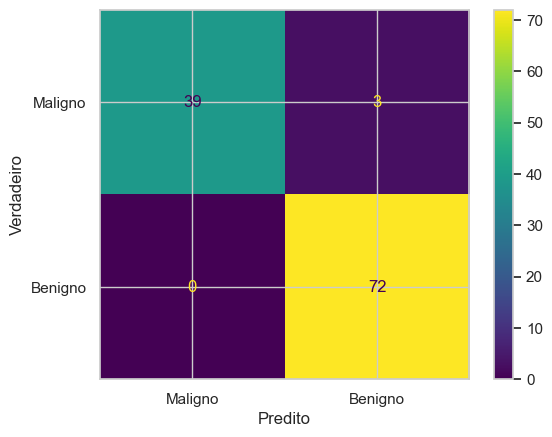


Acurácia: 0.97
Precisão: 1.00
Recall: 0.93
F1-Score: 0.96


In [28]:
print("Métricas da Regressão Logística:\n")
metricas(y_pred_lr)

Métricas do LDA:

Matriz de Confusão:


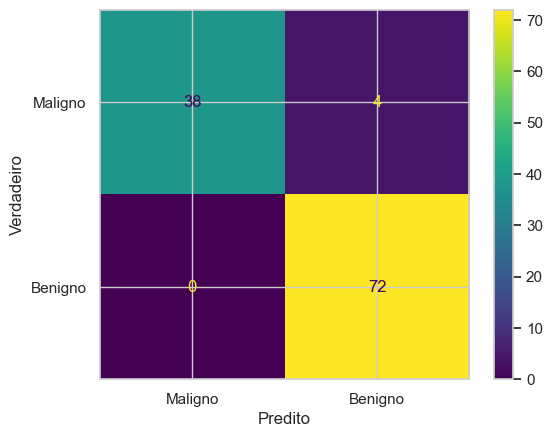


Acurácia: 0.96
Precisão: 1.00
Recall: 0.90
F1-Score: 0.95


In [29]:
print("Métricas do LDA:\n")
metricas(y_pred_lda)

Métricas do QDA:

Matriz de Confusão:


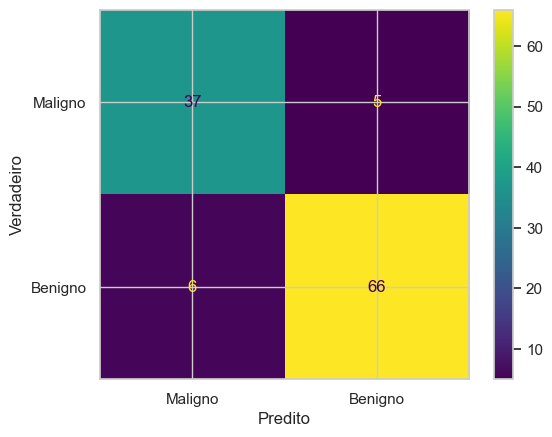


Acurácia: 0.90
Precisão: 0.86
Recall: 0.88
F1-Score: 0.87


In [30]:
print("Métricas do QDA:\n")
metricas(y_pred_qda)

Métricas do Naive Bayes:

Matriz de Confusão:


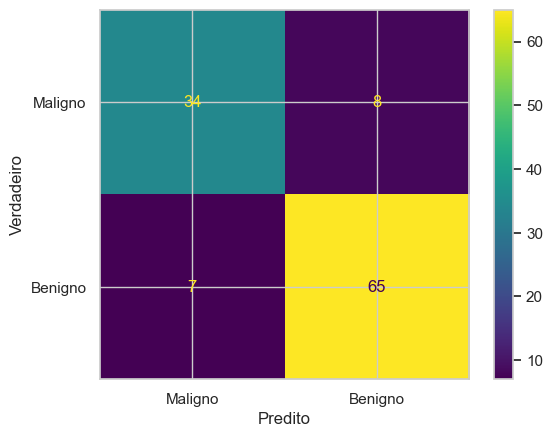


Acurácia: 0.87
Precisão: 0.83
Recall: 0.81
F1-Score: 0.82


In [31]:
print("Métricas do Naive Bayes:\n")
metricas(y_pred_nb)

### 5.2. Métricas II (com K-Fold e ajuste de hiperparâmetros)

Métricas da Regressão Logística (com validação cruzada):

Matriz de Confusão:


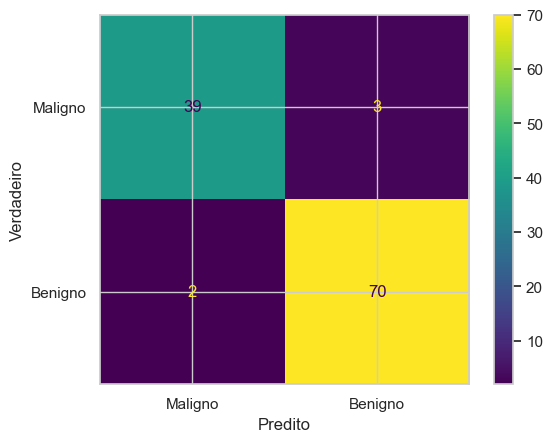


Acurácia: 0.96
Precisão: 0.95
Recall: 0.93
F1-Score: 0.94


In [32]:
print("Métricas da Regressão Logística (com validação cruzada):\n")
metricas(y_pred_lr_cv)

Métricas da LDA (com validação cruzada):

Matriz de Confusão:


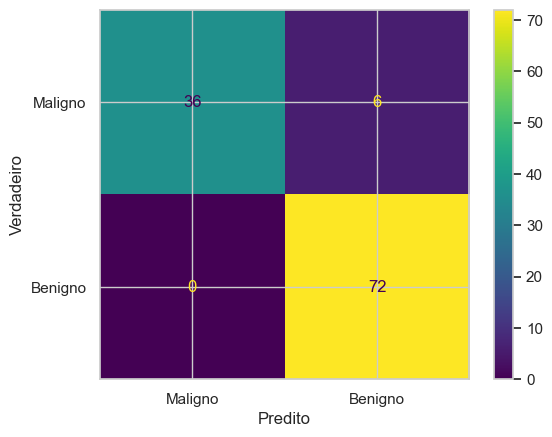


Acurácia: 0.95
Precisão: 1.00
Recall: 0.86
F1-Score: 0.92


In [33]:
print("Métricas da LDA (com validação cruzada):\n")
metricas(y_pred_lda_cv)

Métricas da QDA (com validação cruzada):

Matriz de Confusão:


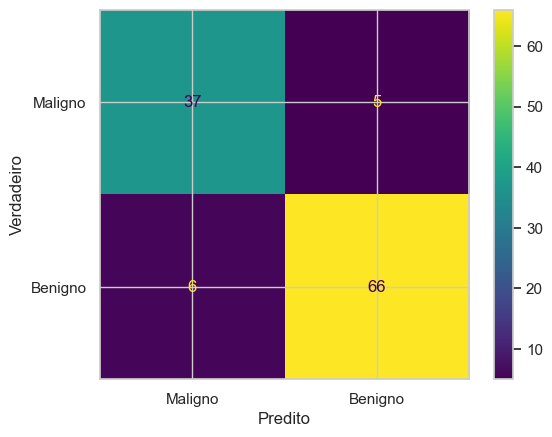


Acurácia: 0.90
Precisão: 0.86
Recall: 0.88
F1-Score: 0.87


In [34]:
print("Métricas da QDA (com validação cruzada):\n")
metricas(y_pred_qda_cv)

Métricas da Naive Bayes (com validação cruzada):

Matriz de Confusão:


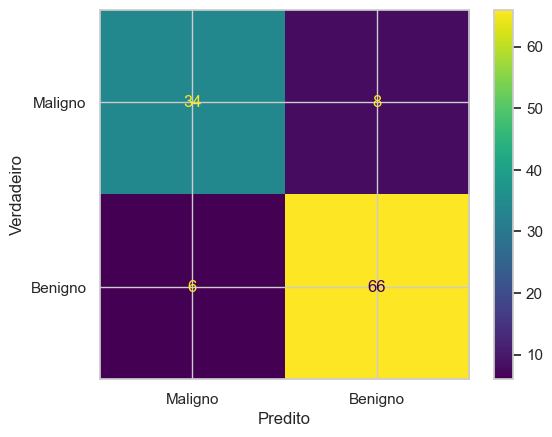


Acurácia: 0.88
Precisão: 0.85
Recall: 0.81
F1-Score: 0.83


In [35]:
print("Métricas da Naive Bayes (com validação cruzada):\n")
metricas(y_pred_nb_cv)

### 5.3. Discussão dos Resultados: O Limite Matemático e o Trade-Off

#### 5.3.1. Sobre a Regressão Logística

Ao compararmos as métricas da Regressão Logística Padrão com a Regressão Logística Otimizada via GridSearchCV (focada em Recall), observamos um fenômeno estatístico muito valioso: o modelo não conseguiu zerar os Falsos Negativos e, de quebra, sofreu uma leve queda na Precisão.

Longe de ser um erro de execução, esse comportamento comprova dois princípios fundamentais do Machine Learning aplicado à saúde:

O Teto de Separação Biológica: O fato de o Recall ter estagnado na casa dos 93% (deixando passar cerca de 3 pacientes) indica que atingimos o limite informacional deste dataset. Estes 3 tumores malignos possuem características geométricas celulares (raio, textura, área) matematicamente indistinguíveis de tumores benignos na visão de um separador linear. Forçar o modelo a tentar "decorar" esses 3 pontos específicos exigiria uma complexidade extrema (overfitting), destruindo a capacidade do modelo de generalizar para novos pacientes.

O Trade-Off Precisão vs. Recall: Ao configurarmos o GridSearchCV para focar no Recall, o modelo tentou ser mais "conservador" clinicamente, jogando uma "rede maior" para tentar capturar os casos malignos escondidos. Como efeito colateral inevitável dessa flexibilização da fronteira de decisão, ele acabou classificando casos benignos limítrofes como malignos (aumentando os Falsos Positivos), o que explica a queda matemática na sua Precisão (que antes era de 100%).

Conclusão da Modelagem:
A Regressão Logística em sua configuração Baseline (Padrão) apresentou o equilíbrio ideal (Sweet Spot) para este conjunto de dados específico. A tentativa de otimização via Validação Cruzada foi uma etapa metodológica indispensável para nos provar, de forma científica e livre de vieses, que o modelo inicial já estava operando em sua eficiência máxima possível, sem ilusões estatísticas.


**Visualização da Fronteira de Decisão (A "Linha" da Regressão Logística)**

Como o modelo enxerga os dados?
A nossa Regressão Logística foi treinada com dezenas de variáveis (raio, textura, área, etc.). Matematicamente, isso significa que ela criou um "hiperplano" em múltiplas dimensões, algo impossível de desenhar em uma tela 2D comum.

Para conseguirmos visualizar a linha de decisão e as observações reais, aplicamos uma técnica chamada PCA (Análise de Componentes Principais). O PCA atua como um "projetor", esmagando as múltiplas dimensões do nosso dataset em apenas duas dimensões principais (os eixos X e Y do nosso gráfico), tentando manter o máximo de informação original possível. Em seguida, treinamos uma Regressão Logística demonstrativa nessas duas dimensões para desenhar a fronteira de decisão.

No gráfico gerado:

A Linha/Fundo de Cor: Representa a regra matemática do modelo. Aonde é azul, ele prevê "Benigno"; aonde é vermelho, ele prevê "Maligno".

Os Pontos: São os pacientes reais.

O Trade-off Visual: Os pontos que caem no lado "errado" da cor (ex: um ponto vermelho na área azul) são exatamente a representação visual dos nossos Falsos Negativos e Falsos Positivos!

(Copie o código abaixo para uma nova célula de código no seu Colab)


#### 5.3.2. Sobre o QDA

Apesar de possuir maior capacidade de modelar relações complexas entre as variáveis, o QDA não superou os modelos lineares. Isso sugere que a separação entre tumores benignos e malignos no conjunto de dados é predominantemente linear, tornando desnecessária a complexidade adicional introduzida pelo modelo quadrático.  

Além disso, como as métricas permaneceram inalteradas após o processo de otimização, há evidências de que a regularização teve pouco impacto sobre o desempenho prático do modelo neste conjunto de dados. Isso demonstra que a fronteira quadrática estimada a partir do conjunto de treino original já era estatisticamente adequada para o problema, e que o processo de validação cruzada (K-Fold) confirmou que qualquer tentativa de aplicar uma regularização matemática mais agressiva reduziria a flexibilidade do modelo, prejudicando o *Recall* no conjunto de teste.

Esse comportamento do QDA reflete as limitações estruturais do algoritmo diante da natureza do problema, dividindo-se em dois cenários:

* **O modelo padrão (sem otimização):** Sofre de *overfitting* severo e instabilidade matemática. Ao tentar criar matrizes de covariância complexas e independentes para as classes de tumores benignos e malignos, o algoritmo perde-se nas variáveis altamente correlacionadas e acaba por "decorar" os ruídos dos dados de treino.
* **O modelo otimizado (com `reg_param`):** A otimização via hiperparâmetros funciona estritamente como um "estabilizador". Ela injeta o ruído matemático necessário apenas para impedir que o cálculo das matrizes colapse, mas não é capaz de elevar o *Recall* a níveis excelentes.

O motivo central para essa falta de evolução reside em uma premissa estatística quebrada. Por definição matemática, o QDA exige que os dados de cada classe sigam uma distribuição Normal (Gaussiana) perfeita. No entanto, as medições biológicas de células cancerígenas são caóticas, irregulares e repletas de *outliers*.

É por essa razão que modelos baseados em premissas menos rígidas e fronteiras mais simples, como a Regressão Logística, alcançam desempenhos superiores neste cenário.

#### 5.3.3 Demais Modelos

**LDA (Análise Discriminante Linear)**
O LDA demonstrou uma rigidez excessiva ao impor a restrição de que ambas as classes compartilhem exatamente a mesma matriz de covariância. Embora beneficie de uma separação de classes que é majoritariamente linear, essa exigência de homogeneidade impede o algoritmo de se ajustar às diferenças de dispersão e às variações morfológicas específicas que distinguem os tecidos benignos dos malignos, limitando o seu poder de generalização.

**Naive Bayes**
O Naive Bayes obteve o desempenho mais frágil por assumir a independência absoluta entre as variáveis preditoras, uma premissa completamente violada pela natureza do problema. Ao ignorar as fortes correlações lineares e geométricas intrínsecas às características celulares — onde o raio de um núcleo determina diretamente o seu perímetro e a sua área —, o modelo descarta interações críticas para a identificação precisa de anomalias, resultando em classificações menos confiáveis.

#### 5.3.4. Plots

Gerando os gráficos das fronteiras de decisão...


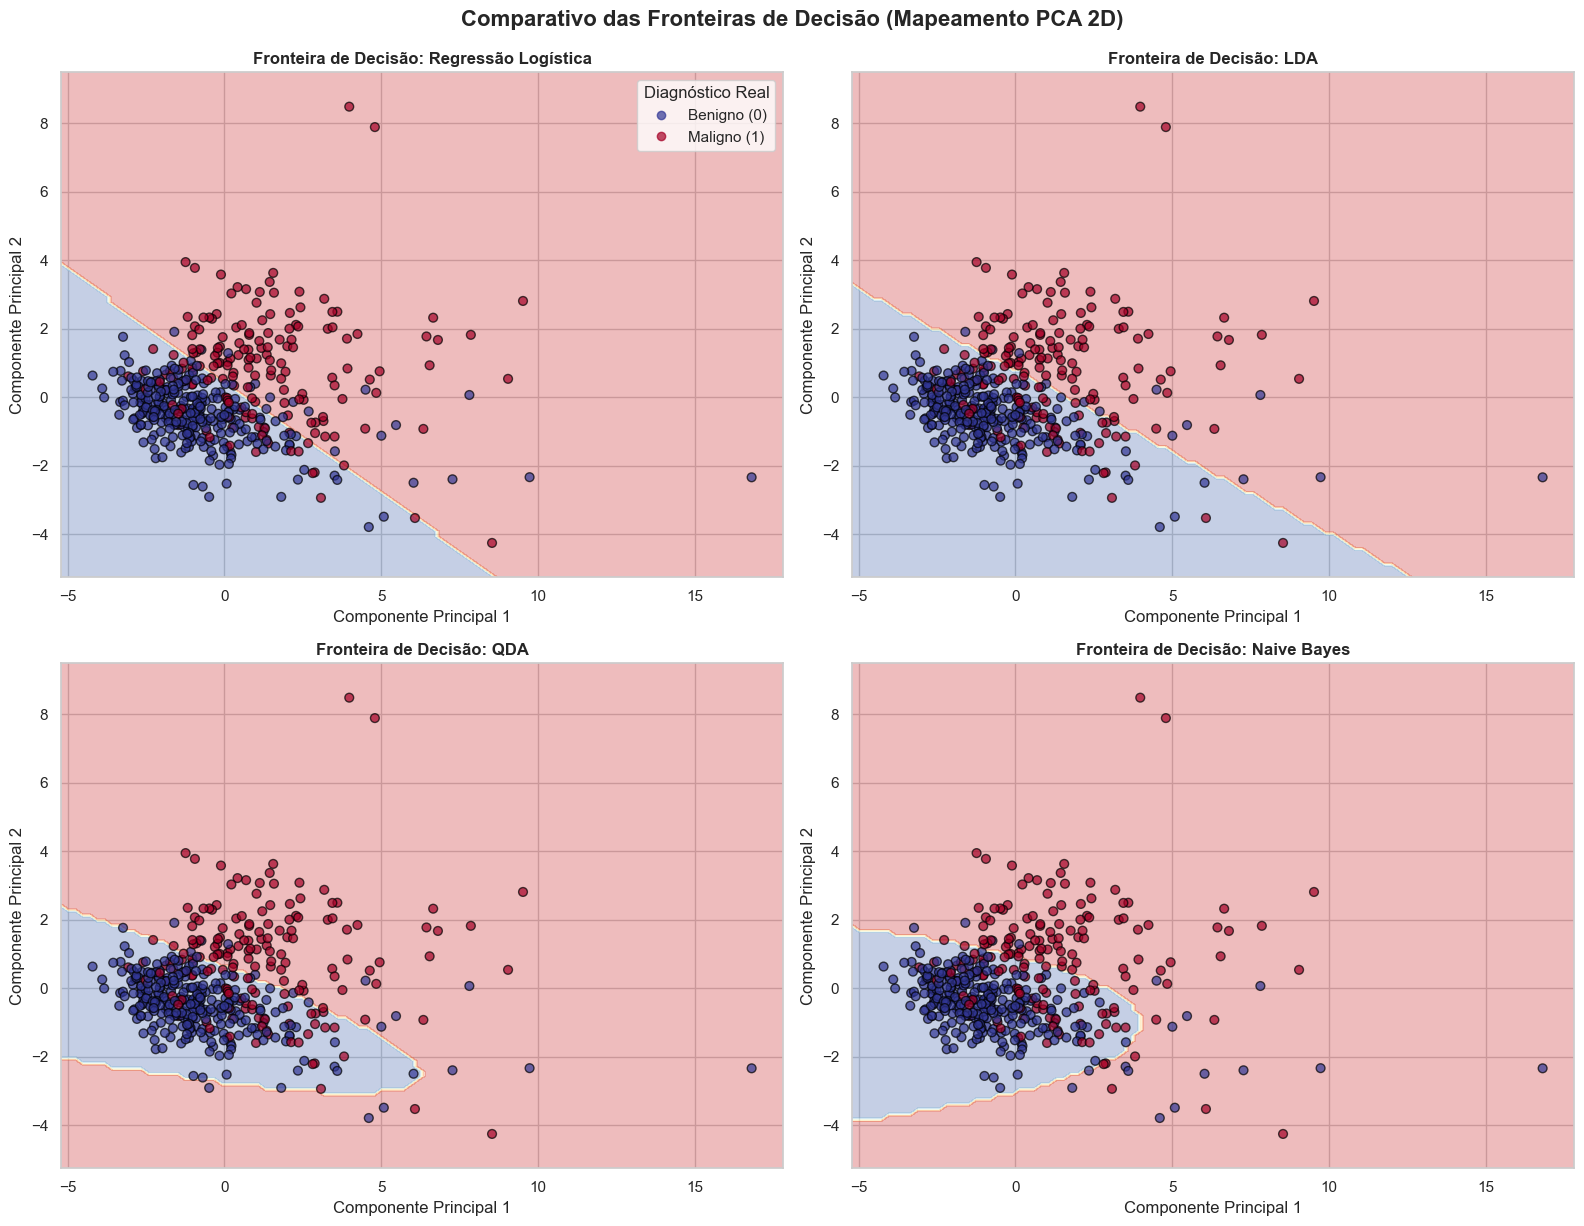

In [36]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

print("Gerando os gráficos das fronteiras de decisão...")

# 1. Aplicando PCA para reduzir para 2 Dimensões (Necessário para plotar em 2D)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# 2. Configurando a grade de subplots (2 linhas e 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel() # Transforma a matriz de eixos em uma lista linear para facilitar o loop

# Lista com os nomes dos modelos na mesma ordem para iterar
nomes_modelos = ['Regressão Logística', 'LDA', 'QDA', 'Naive Bayes']

for i, nome in enumerate(nomes_modelos):
    ax = axes[i]

    # Pegamos o modelo que você já tunou e treinou no GridSearch
    # Como o PCA mudou o formato dos dados (agora são 2D), precisamos dar um rápido .fit no espaço 2D apenas para o plot conseguir desenhar a fronteira
    modelo_2d = melhores_modelos[nome]
    modelo_2d.fit(X_train_pca, y_train)

    # 3. Desenhando a Fronteira de Decisão (o fundo colorido)
    # Note como a do LDA será reta e a do QDA/Naive Bayes serão curvas!
    DecisionBoundaryDisplay.from_estimator(
        modelo_2d, X_train_pca, response_method="predict",
        cmap="RdYlBu_r", alpha=0.3, ax=ax,
        xlabel="Componente Principal 1",
        ylabel="Componente Principal 2"
    )

    # 4. Plotando os pontos reais do treino
    scatter = ax.scatter(
        X_train_pca[:, 0], X_train_pca[:, 1],
        c=y_train, cmap="RdYlBu_r",
        edgecolors='black', s=40, alpha=0.7
    )

    # 5. Customização de cada gráfico
    ax.set_title(f"Fronteira de Decisão: {nome}", fontsize=12, fontweight='bold')

    # Adiciona a legenda apenas no primeiro gráfico para não poluir
    if i == 0:
        handles, labels = scatter.legend_elements()
        ax.legend(handles, ["Benigno (0)", "Maligno (1)"], title="Diagnóstico Real", loc="upper right")

plt.tight_layout()
plt.suptitle("Comparativo das Fronteiras de Decisão (Mapeamento PCA 2D)", y=1.02, fontsize=16, fontweight='bold')
plt.show()


## 6. Documentação/ética

### Ética e Impacto Social do Modelo

A aplicação de algoritmos de Aprendizado de Máquina no diagnóstico de câncer de mama envolve responsabilidades éticas críticas, uma vez que as decisões do modelo impactam diretamente a vida, o bem-estar psicológico e a sobrevivência de pacientes. Esta discussão divide-se em três pilares essenciais.

#### O Peso Assimétrico dos Erros (Falsos Negativos vs. Falsos Positivos)

Na classificação clínica, os erros do modelo não possuem o mesmo peso humano ou social. Um Falso Positivo (classificar um tumor benigno como maligno) gera ansiedade severa e submete a paciente a biópsias e exames estressantes desnecessários; contudo, o erro é rapidamente corrigido por exames subsequentes. Por outro lado, um Falso Negativo (classificar um tumor maligno como benigno) é um erro catastrófico. Ele priva a paciente do tratamento precoce, permitindo a progressão silenciosa da doença, o que reduz drasticamente as chances de cura. Sob a ótica ética do princípio da não-maleficência, justifica-se a escolha do grupo em priorizar a otimização do Recall (Sensibilidade) no GridSearchCV, garantindo que o sistema seja rigoroso na identificação de possíveis malignidades.


#### IA como Suporte à Decisão e não como Substituta Humana

Nenhum modelo estatístico — seja a Regressão Logística ou abordagens discriminantes como LDA e QDA — deve ser interpretado como um diagnóstico final autônomo. Eticamente, estes sistemas devem atuar estritamente como ferramentas de suporte à decisão clínica (segunda opinião). O papel da IA é automatizar a triagem de características celulares complexas obtidas por agulha fina (PAAF), alertando o corpo médico para casos de alto risco, mas a validação e a palavra final devem permanecer obrigatoriamente sob a responsabilidade do médico especialista.

#### Viés de Dados, Representatividade e Generalização

O conjunto de dados Breast Cancer Wisconsin foi coletado na década de 1990 em uma região geográfica e demográfica específica dos Estados Unidos. Eticamente, é imperativo reconhecer a limitação de generalização deste modelo. Fatores genéticos, ambientais e perfis epidemiológicos variam entre diferentes etnias e populações globais (como a população brasileira). Utilizar este modelo de forma universal sem uma validação prévia com dados locais e diversificados violaria o princípio da equidade na saúde, podendo gerar subdiagnósticos em grupos sub-representados na base original.

## 7. Previsão Final no Conjunto test2.csv (base sem rótulos)

O arquivo `test2.csv` **não possui a coluna `diagnosis`**, ou seja, não temos o "gabarito" dessas amostras. Consequentemente, **não é possível calcular métricas** (Recall, F1, matriz de confusão) sobre ele — essas métricas foram calculadas sobre a validação interna do `train2` nas Seções 5.x.

O que podemos (e devemos) fazer aqui é **gerar as previsões**. Para aproveitar o máximo de informação, os modelos finais são **retreinados usando todo o `train2`** (as 569 amostras rotuladas), aplicando exatamente o mesmo pré-processamento (corte de features correlacionadas + escala) aprendido a partir dos dados de treino.

In [37]:
# =====================================================================
# 7.1. Pré-processa o test2 e gera as previsões dos 4 modelos
# =====================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

# 1. Alinha o test2 às MESMAS features do treino, na mesma ordem
X_test2 = df_test2.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
X_test2 = X_test2[X.columns]

# 2. Aplica o MESMO corte de features correlacionadas (to_drop, definido na Seção 3.1)
X_full_filtered  = X.drop(columns=to_drop)         # todo o train2 (rotulado)
X_test2_filtered = X_test2.drop(columns=to_drop)   # test2

# 3. Reajusta a escala usando TODO o train2 e apenas transforma o test2
#    (respeita a mesma escolha de escala feita na Seção 3.3)
scaler_final = StandardScaler() if TIPO_ESCALA == 'padrao' else RobustScaler()
X_full_scaled  = scaler_final.fit_transform(X_full_filtered)
X_test2_scaled = scaler_final.transform(X_test2_filtered)

# 4. Retreina cada modelo em TODO o train2 e prevê o test2
modelos_finais = {
    'Regressao_Logistica': LogisticRegression(max_iter=10000, random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Naive_Bayes': GaussianNB(),
}

previsoes_test2 = pd.DataFrame()
for nome, modelo in modelos_finais.items():
    modelo.fit(X_full_scaled, y)
    pred = modelo.predict(X_test2_scaled)
    previsoes_test2[nome] = pd.Series(pred).map({1: 'M', 0: 'B'})

previsoes_test2.index.name = 'indice'
print(f"Previsões geradas para {len(previsoes_test2)} amostras do test2 (M = maligno, B = benigno).\n")
previsoes_test2

Previsões geradas para 40 amostras do test2 (M = maligno, B = benigno).



,Regressao_Logistica,LDA,QDA,Naive_Bayes
indice,,,,
0,B,B,B,B
1,B,B,B,M
2,B,B,B,M
3,M,B,M,M
4,B,B,M,B
5,M,M,M,M
6,B,B,B,B
7,B,B,B,B
8,B,B,M,B


In [38]:
# =====================================================================
# 7.2. Salva as previsões em CSV
# =====================================================================
# A Regressão Logística foi eleita o modelo final (ver conclusão da Seção 5.3.1).
saida = previsoes_test2[['Regressao_Logistica']].rename(columns={'Regressao_Logistica': 'diagnosis'})
saida.to_csv('previsoes_test2.csv', index=False)

print("Arquivo 'previsoes_test2.csv' salvo com sucesso!")
print("\nDistribuição das previsões:")
print(saida['diagnosis'].value_counts())
saida.head(10)

Arquivo 'previsoes_test2.csv' salvo com sucesso!

Distribuição das previsões:
diagnosis
B    24
M    16
Name: count, dtype: int64


,diagnosis
indice,
0,B
1,B
2,B
3,M
4,B
5,M
6,B
7,B
8,B
